## Métricas de Qualidade - Backend (SonarCloud)

Esta seção apresenta a análise automatizada da saúde técnica do backend, utilizando dados extraídos via API do **SonarCloud**. O dashboard utiliza conceitos avançados de **Engenharia de Software** para transformar métricas brutas em indicadores de decisão.

### Definição das Métricas

* **ncloc (Lines of Code):** Quantidade de linhas de código lógico, utilizada como base para o cálculo de densidade.
* **Ratings (A-E):** Avaliação qualitativa de **Reliability** (Confiabilidade), **Security** (Segurança) e **Maintainability** (Manutenibilidade).
* **Issues por Densidade (KLOC):** Bugs, Vulnerabilidades e Code Smells calculados a cada 1.000 linhas de código. Isso permite uma comparação justa entre diferentes tamanhos de projeto.
* **Coverage:** Percentual de linhas protegidas por testes unitários e de integração.

---

### Análise e Interpretação dos Resultados

#### 1. Índice de Qualidade Geral (Quality Score)
Diferente de dashboards comuns, o nosso **Quality Score** é um indicador composto e normalizado por densidade, seguindo a fórmula:

$$QualityScore = (Cov_{norm} \cdot 0.35) + (Vuln_{norm} \cdot 0.25) + (Bugs_{norm} \cdot 0.20) + (Smells_{norm} \cdot 0.10) + (Dup_{norm} \cdot 0.10)$$

* **Nível ALTA (>= 0.8):** Alta maturidade técnica. O projeto equilibra segurança, testes e manutenibilidade.
* **Nível MÉDIA (0.5 - 0.79):** Alerta para o acúmulo de dívida técnica ou queda na cobertura de testes.
* **Nível BAIXA (< 0.5):** Risco crítico. Necessidade de interrupção para refatoração e correção de vulnerabilidades.

#### 2. Densidade de Issues (KLOC)
O gráfico de **Densidade** é o nosso principal termômetro de qualidade. Em vez de olhar apenas o número absoluto de bugs, avaliamos se a frequência de erros está aumentando proporcionalmente ao tamanho do código.
* **Vulnerabilidades:** Possuem o maior peso negativo, pois comprometem a integridade do sistema.
* **Bugs:** Indicam falhas na lógica de negócio que devem ser mitigadas com melhores práticas de QA.

#### 3. Qualidade Estrutural e Cobertura
A análise visual de pizza e barras foca no equilíbrio do **Pipeline de CI**:
* **Testes:** Buscamos manter a cobertura acima de 80% para garantir refatorações seguras.
* **Duplicação:** Monitoramos para manter o código enxuto, respeitando o princípio **DRY** (*Don't Repeat Yourself*).

---
> A transição para uma análise baseada em **Densidade (KLOC)** segue os padrões de mercado para métricas de software (ISO/IEC 25010). Isso garante que o dashboard permaneça útil e preciso à medida que o repositório `RetinaScan-Api` cresce, evitando que números absolutos mascarem a real qualidade do produto.

Arquivos encontrados: 2


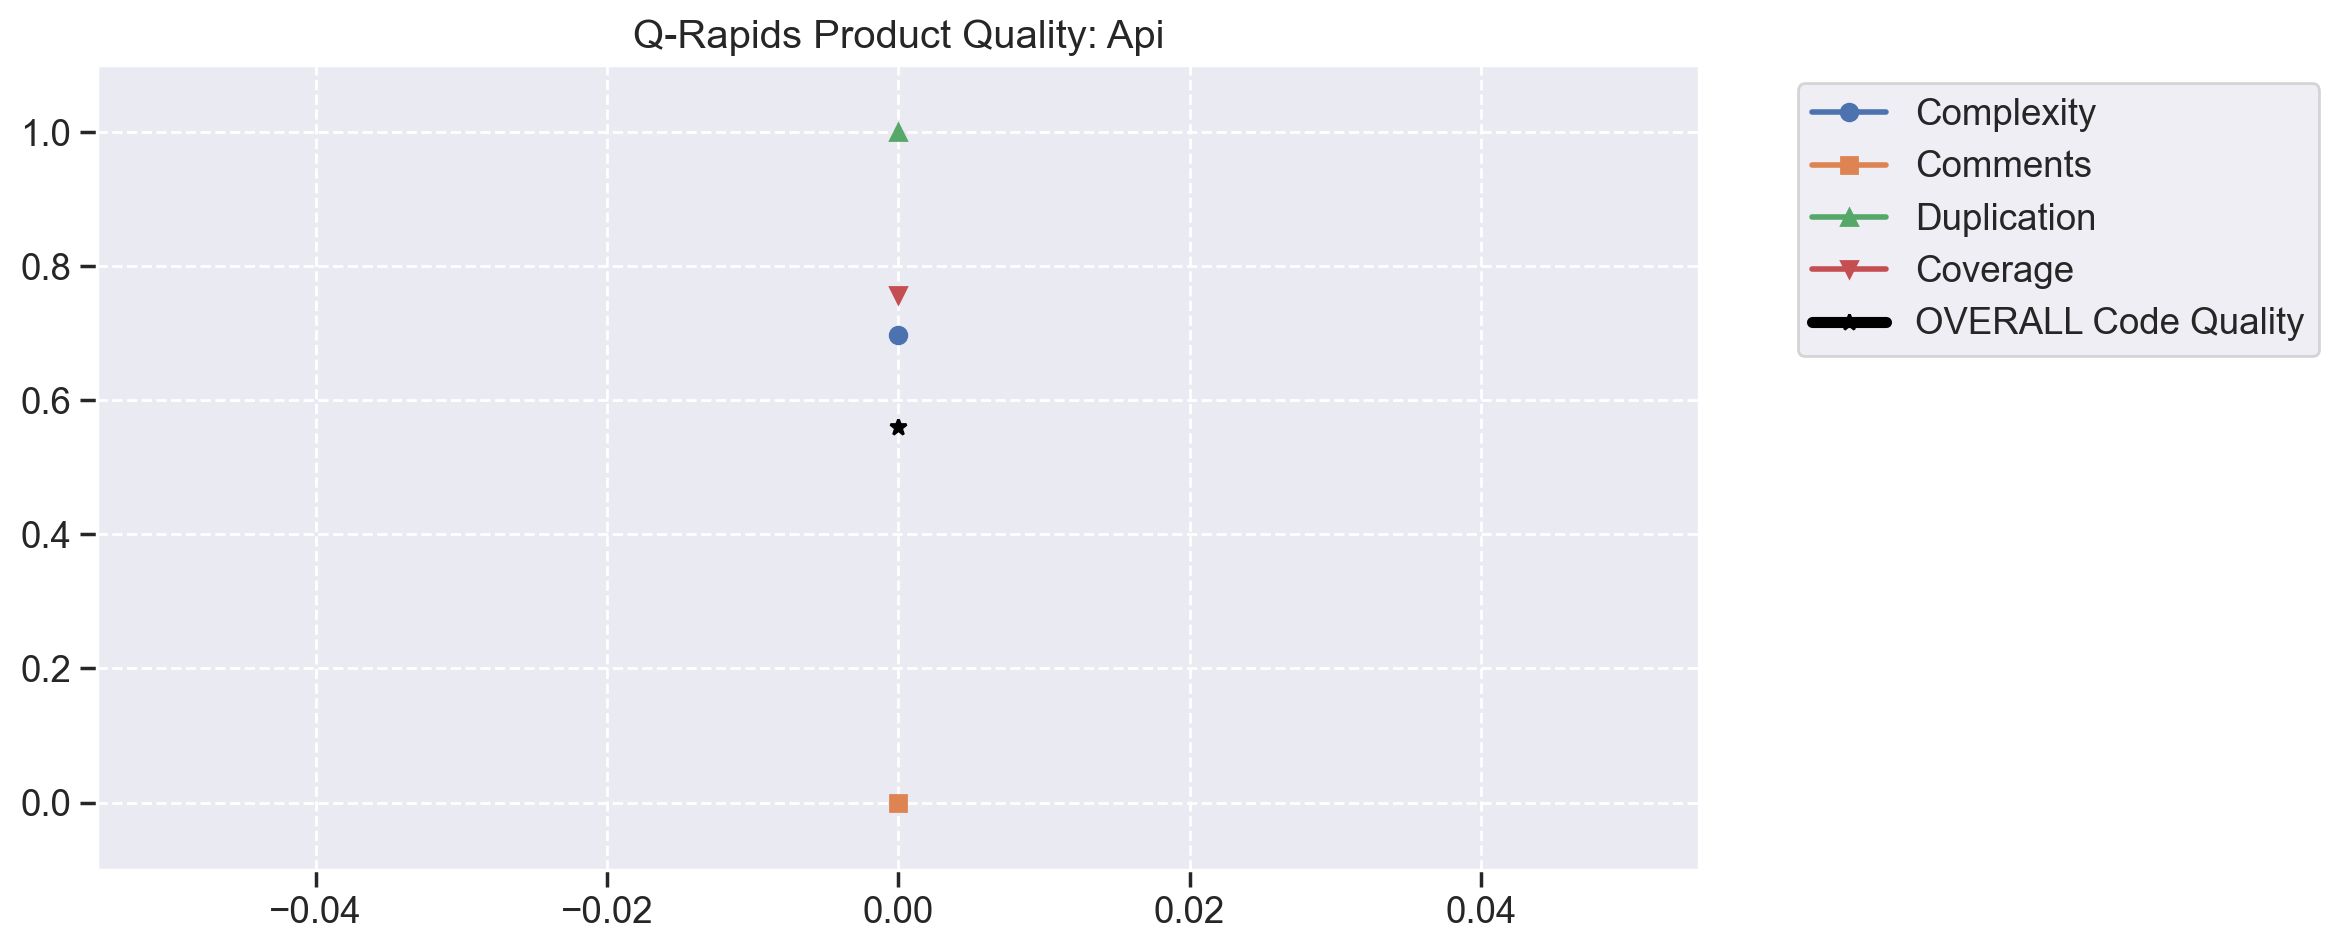

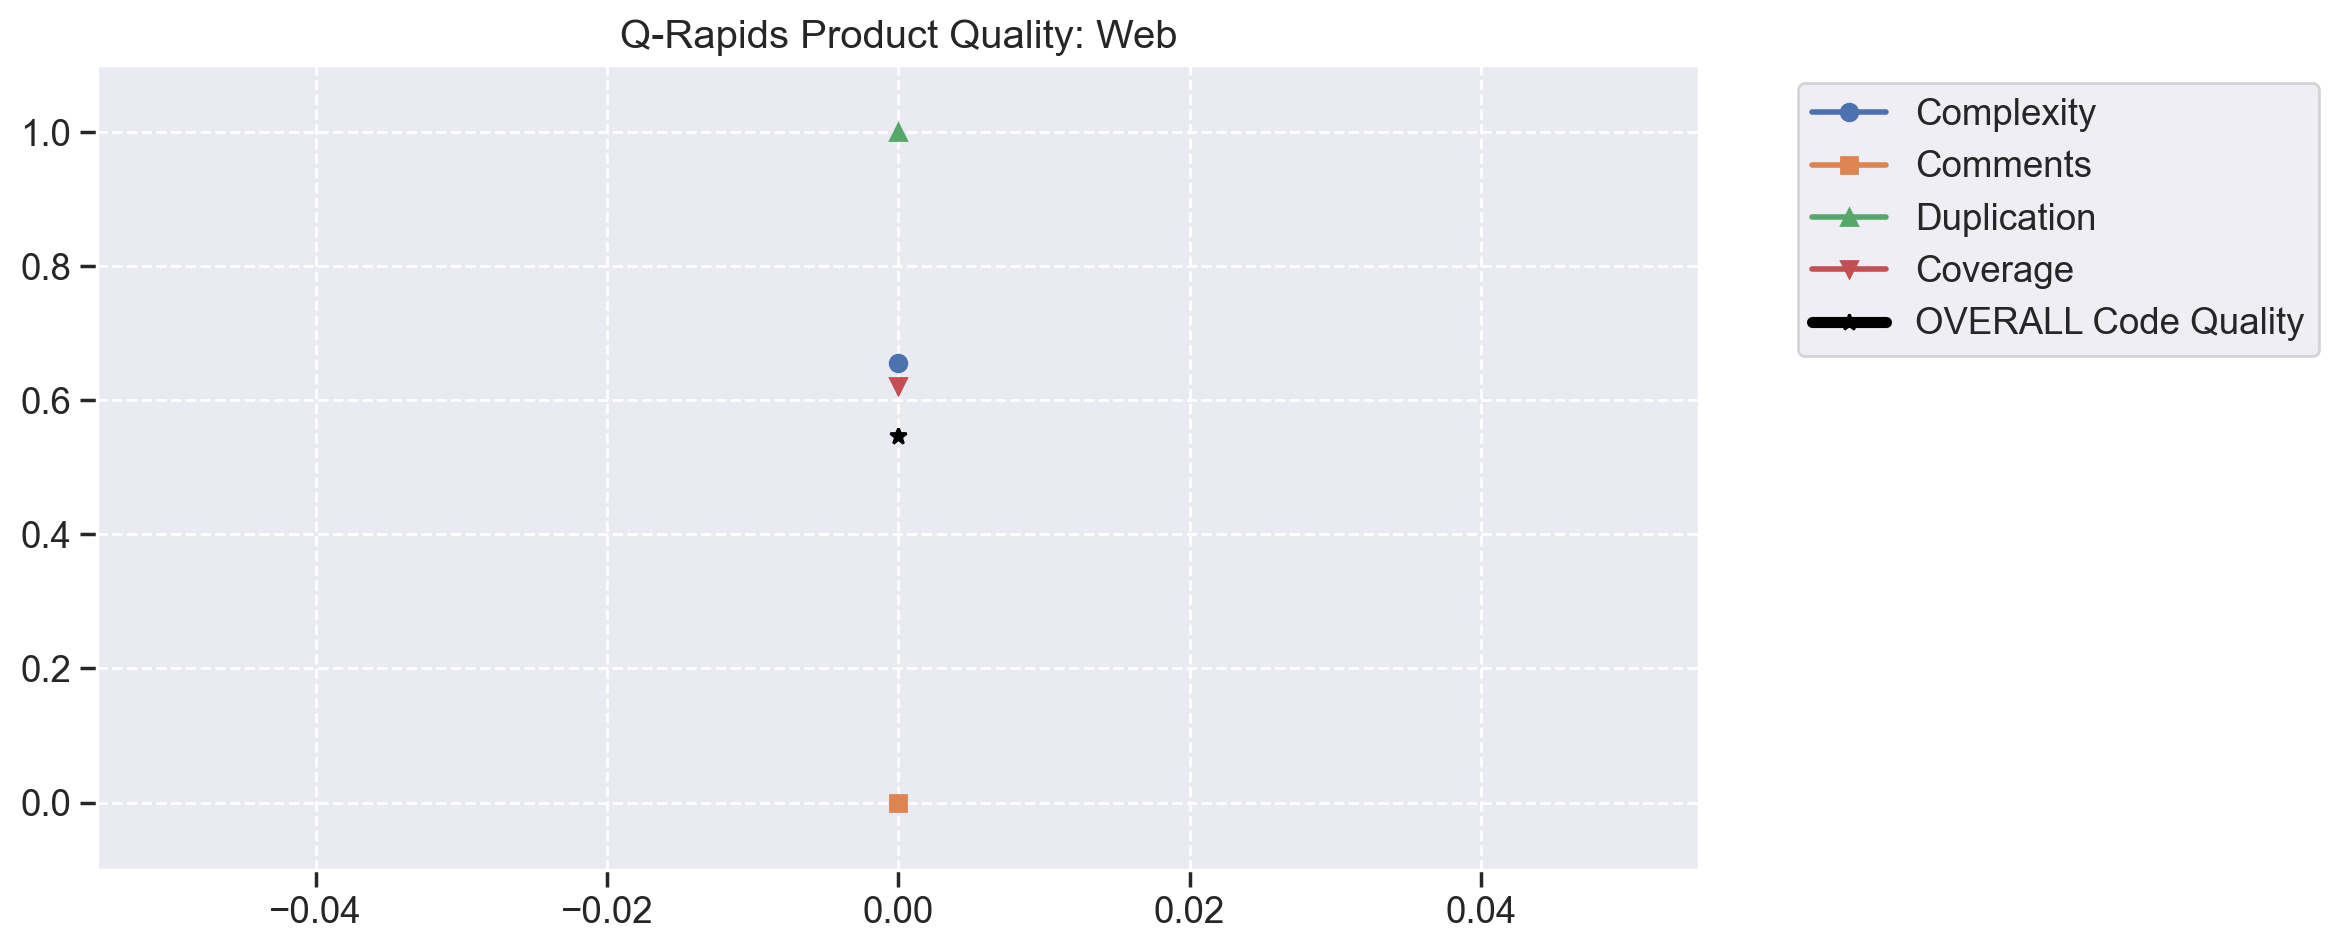

In [ ]:
import pandas as pd
import json
from glob import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
import datetime

%config InlineBackend.figure_format ='retina'
sns.set(font_scale=1.2)
sns.set_style('darkgrid', {'xtick.bottom' : True, 'ytick.left': True, 'grid.linestyle':'--', 'axes.edgecolor' : 'white'})

repo_major_name = 'fga-eps-mds-2026-1-RetinaScan-'
repos_language = {
    'Web': 'ts',
    'Api': 'ts'
}

metric_list = ['files', 'functions', 'complexity', 'comment_lines_density', 
               'duplicated_lines_density', 'coverage', 'ncloc', 'tests', 
               'test_errors', 'test_failures', 'test_execution_time', 'security_rating']

def unmarshall(json_path: str) -> dict:
    with open(json_path, encoding='utf-8') as json_file:
        return json.load(json_file)

def get_files_df(df: pd.DataFrame) -> pd.DataFrame:
    return df[df['qualifier'] == 'FIL'].dropna(subset=['functions', 'complexity', 'comment_lines_density', 'duplicated_lines_density', 'coverage'])

def get_dir_df(df: pd.DataFrame) -> pd.DataFrame:
    dirs = df[df["qualifier"] == "DIR"]
    if dirs.empty: return pd.Series()
    return dirs.loc[pd.to_numeric(dirs["tests"], errors='coerce').fillna(0).idxmax()]

def get_uts_df(df: pd.DataFrame) -> pd.DataFrame:
    return df[df['qualifier'] == 'UTS'].fillna(0)

def metric_per_file(json_dict: dict) -> List[dict]:
    file_json = []
    components = json_dict.get('components', [])
    for component in components:
        ncloc_value = 0
        for measure in component.get('measures', []):
            if measure['metric'] == 'ncloc':
                ncloc_value = float(measure['value'])
                break
        if (component['qualifier'] == 'FIL' and ncloc_value > 0) or component['qualifier'] in ['DIR', 'UTS']:
            file_json.append(component)
    return file_json

def generate_component_dataframe_data(metrics_list, file_component_data, language_extension):
    rows = []
    for file in file_component_data:
        row = {m: 0 for m in metrics_list}
        row['qualifier'] = file.get('qualifier')
        row['language'] = file.get('language')
        row['path'] = file.get('path')
        for measure in file.get('measures', []):
            if measure['metric'] in metrics_list:
                row[measure['metric']] = measure['value']
        rows.append(row)
    
    df = pd.DataFrame(rows)
    files_df = df[(df['qualifier'] == 'FIL') & (df['language'] == language_extension)]
    dirs_df = df[df['qualifier'] == 'DIR']
    uts_df = df[df['qualifier'] == 'UTS']
    return pd.concat([files_df, dirs_df, uts_df], axis=0)

def _ncloc(df): 
    return pd.to_numeric(df['ncloc'], errors='coerce').sum()

def complexity_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['complexity'].astype(float) / f_df['functions'].astype(float)) < 10]) / len(f_df)

def comments_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['comment_lines_density'].astype(float) > 10) & (f_df['comment_lines_density'].astype(float) < 30)]) / len(f_df)

def duplication_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['duplicated_lines_density'].astype(float) < 5)]) / len(f_df)

def coverage_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['coverage'].astype(float) > 60)]) / len(f_df)

def create_metrics_df(df):
    versions = df['datetime'].unique()
    res = []
    for v in versions:
        v_df = df[df['datetime'] == v]
        res.append({
            'complexity': complexity_factor(v_df),
            'comments': comments_factor(v_df),
            'duplication': duplication_factor(v_df),
            'coverage': coverage_factor(v_df),
            'repository': v_df['repository'].iloc[0],
            'version': v,
            'ncloc': _ncloc(v_df)
        })
    return pd.DataFrame(res)

def create_component_df(json_list):
    df_final = pd.DataFrame()
    for json_path in json_list:
        try:
            file_component = unmarshall(json_path)
            base_name = os.path.basename(json_path)
            parts = base_name.split("-")
            if len(parts) < 7: continue
            repo_part = parts[6] 
            
            file_component_data = metric_per_file(file_component)
            if not file_component_data: continue
                
            file_df = generate_component_dataframe_data(metric_list, file_component_data, repos_language.get(repo_part, 'ts'))
            if file_df.empty: continue

            file_df['filename'] = base_name
            file_df['repository'] = repo_major_name + repo_part
            file_df['datetime'] = "-".join(parts[7:13])
            file_df['version'] = parts[13].replace(".json", "") if len(parts) > 13 else "0.0.1"
            
            df_final = pd.concat([df_final, file_df], ignore_index=True)
        except Exception as e:
            print(f"Erro no arquivo {base_name}: {e}")
    return df_final

sonar_files = glob('analytics/raw-data/fga-eps-mds-*.json')
if not sonar_files:
    sonar_files = glob('raw-data/fga-eps-mds-*.json')

print(f"Arquivos encontrados: {len(sonar_files)}")

file_component_df = create_component_df(sonar_files)

if not file_component_df.empty:
    repos_results = []
    unique_repos = file_component_df['repository'].unique()
    
    for r_name in unique_repos:
        simple_name = r_name.replace(repo_major_name, "")
        df_repo = file_component_df[file_component_df['repository'] == r_name]
        
        m_df = create_metrics_df(df_repo)
        
        # Cálculo de Code Quality (Média dos fatores de manutenibilidade)
        m_df['code_quality'] = (m_df['complexity']*0.33 + m_df['comments']*0.33 + m_df['duplication']*0.33)
        
        plt.figure(figsize=(12, 5))
        plt.plot(m_df['complexity'], label="Complexity", marker='o', linewidth=2)
        plt.plot(m_df['comments'], label="Comments", marker='s', linewidth=2)
        plt.plot(m_df['duplication'], label="Duplication", marker='^', linewidth=2)
        plt.plot(m_df['coverage'], label="Coverage", marker='v', linewidth=2)
        plt.plot(m_df['code_quality'], label="OVERALL Code Quality", marker='*', linewidth=4, color='black')
        
        plt.ylim(-0.1, 1.1)
        plt.title(f"Q-Rapids Product Quality: {simple_name}")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print("Nenhum dado processado. Verifique os caminhos e arquivos.")

## Métricas de Qualidade - Frontend (SonarCloud)

Esta seção detalha a qualidade técnica da interface do **RetinaScan-Web**. No desenvolvimento frontend, manter a manutenibilidade e a baixa densidade de *Code Smells* é crucial para garantir uma UI fluida e livre de efeitos colaterais.

### Métricas Estratégicas

* **Maintainability (Manutenibilidade):** Essencial para o frontend, avalia a facilidade de evolução dos componentes e hooks.
* **Security & Vulnerabilities:** Monitora riscos em dependências e manipulação de dados no lado do cliente.
* **Densidade por KLOC:** Normaliza a quantidade de problemas pelo tamanho da base de código (Lines of Code), permitindo medir a eficiência do desenvolvimento à medida que a aplicação cresce.

---

### Análise do Quality Score (Front)

O cálculo do score segue o mesmo rigor aplicado ao backend, garantindo que o projeto mantenha uma barra de qualidade única:

$$QualityScore = (Cov_{norm} \cdot 0.35) + (Vuln_{norm} \cdot 0.25) + (Bugs_{norm} \cdot 0.20) + (Smells_{norm} \cdot 0.10) + (Dup_{norm} \cdot 0.10)$$

* **Foco em Cobertura:** Para o frontend, priorizamos a cobertura de componentes críticos e fluxos de usuário, visando mitigar bugs de interface que afetam diretamente a experiência do usuário.
* **Saúde Estrutural:** A baixa duplicação de código reflete o uso eficiente de componentes reutilizáveis e o respeito aos padrões de design de software.


In [5]:
# Analytics - Product Quality
# Date: 2026/04
# SUMMARY: Análise de qualidade do projeto RetinaScan seguindo o modelo Q-Rapids.

import pandas as pd
import json
from glob import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
import datetime

# --- GRAPH SETTINGS ---
%config InlineBackend.figure_format ='retina'
sns.set(font_scale=1.2)
sns.set_style('darkgrid', {'xtick.bottom' : True, 'ytick.left': True, 'grid.linestyle':'--', 'axes.edgecolor' : 'white'})

# --- CONFIGURATION ---
# Ajustado para o padrão dos seus arquivos
repo_major_name = 'fga-eps-mds-2026-1-RetinaScan-'
repos_language = {
    'Web': 'ts',
    'Api': 'ts'
}

# --- SONARCLOUD DATA LOADING ---
sonar_files = glob('analytics/raw-data/fga-eps-mds-*.json')

def unmarshall(json_path: str) -> dict:
    with open(json_path, encoding='utf-8') as json_file:
        return json.load(json_file)

metric_list = ['files', 'functions', 'complexity', 'comment_lines_density', 
               'duplicated_lines_density', 'coverage', 'ncloc', 'tests', 
               'test_errors', 'test_failures', 'test_execution_time', 'security_rating']

def get_files_df(df: pd.DataFrame) -> pd.DataFrame:
    return df[df['qualifier'] == 'FIL'].dropna(subset=['functions', 'complexity', 'comment_lines_density', 'duplicated_lines_density', 'coverage'])

def get_dir_df(df: pd.DataFrame) -> pd.DataFrame:
    dirs = df[df["qualifier"] == "DIR"]
    if dirs.empty: return pd.Series()
    return dirs.loc[pd.to_numeric(dirs["tests"], errors='coerce').fillna(0).idxmax()]

def get_uts_df(df: pd.DataFrame) -> pd.DataFrame:
    return df[df['qualifier'] == 'UTS'].fillna(0)

def metric_per_file(json_dict: dict) -> List[dict]:
    file_json = []
    # Adaptado para o seu JSON que usa 'components' e 'baseComponent'
    components = json_dict.get('components', [])
    for component in components:
        ncloc_value = 0
        for measure in component.get('measures', []):
            if measure['metric'] == 'ncloc':
                ncloc_value = float(measure['value'])
                break
        if (component['qualifier'] == 'FIL' and ncloc_value > 0) or component['qualifier'] in ['DIR', 'UTS']:
            file_json.append(component)
    return file_json

def generate_component_dataframe_data(metrics_list, file_component_data, language_extension):
    df_columns = metrics_list + ['qualifier', 'language', 'path']
    rows = []
    for file in file_component_data:
        row = {m: 0 for m in metrics_list}
        row['qualifier'] = file.get('qualifier')
        row['language'] = file.get('language')
        row['path'] = file.get('path')
        for measure in file.get('measures', []):
            if measure['metric'] in metrics_list:
                row[measure['metric']] = measure['value']
        rows.append(row)
    
    df = pd.DataFrame(rows)
    # Filtros por tipo e linguagem
    files_df = df[(df['qualifier'] == 'FIL') & (df['language'] == language_extension)]
    dirs_df = df[df['qualifier'] == 'DIR']
    uts_df = df[df['qualifier'] == 'UTS']
    return pd.concat([files_df, dirs_df, uts_df], axis=0)

def create_component_df(json_list):
    df_final = pd.DataFrame()
    for json_path in json_list:
        file_component = unmarshall(json_path)
        base_name = os.path.basename(json_path)
        
        # Extrai o nome do repo (Web ou Api) - index 6 conforme seu nome de arquivo
        repo_part = base_name.split("-")[6] 
        
        file_component_data = metric_per_file(file_component)
        file_df = generate_component_dataframe_data(metric_list, file_component_data, repos_language.get(repo_part, 'ts'))
        
        file_df['filename'] = base_name
        # Regex ajustada para capturar Data e Versão do seu arquivo
        aux_df = base_name.split(repo_part + "-")[1].replace(".json", "").split("-")
        file_df['repository'] = repo_major_name + repo_part
        file_df['datetime'] = "-".join(aux_df[:6])
        file_df['version'] = "-".join(aux_df[6:])
        
        df_final = pd.concat([df_final, file_df], ignore_index=True)
    return df_final.sort_values(by=['repository', 'datetime'])

# Execução do carregamento
file_component_df = create_component_df(sonar_files)

# --- Q-RAPIDS CALCULATIONS ---
def _ncloc(df): return pd.to_numeric(df['ncloc'], errors='coerce').sum()

def complexity_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['complexity'].astype(float) / f_df['functions'].astype(float)) < 10]) / len(f_df)

def comments_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['comment_lines_density'].astype(float) > 10) & (f_df['comment_lines_density'].astype(float) < 30)]) / len(f_df)

def duplication_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['duplicated_lines_density'].astype(float) < 5)]) / len(f_df)

def coverage_factor(df):
    f_df = get_files_df(df)
    if f_df.empty: return 0
    return len(f_df[(f_df['coverage'].astype(float) > 60)]) / len(f_df)

def create_metrics_df(df):
    versions = df['datetime'].unique()
    res = []
    for v in versions:
        v_df = df[df['datetime'] == v]
        res.append({
            'complexity': complexity_factor(v_df),
            'comments': comments_factor(v_df),
            'duplication': duplication_factor(v_df),
            'coverage': coverage_factor(v_df),
            'repository': v_df['repository'].iloc[0],
            'version': v,
            'ncloc': _ncloc(v_df)
        })
    return pd.DataFrame(res)

# Agrupando por repositório
repos_dataframes = []
for repo in repos_language.keys():
    name = repo_major_name + repo
    df_repo = file_component_df[file_component_df['repository'] == name]
    if not df_repo.empty:
        repos_dataframes.append({'name': repo, 'df': create_metrics_df(df_repo)})

# --- VISUALIZATION ---
for item in repos_dataframes:
    name, data = item['name'], item['df']
    # Cálculo das Agregações (Maintainability)
    data['code_quality'] = (data['complexity']*0.33 + data['comments']*0.33 + data['duplication']*0.33)
    
    plt.figure(figsize=(12, 6))
    plt.plot(data['complexity'], label="Complexity", marker='o')
    plt.plot(data['comments'], label="Comments", marker='s')
    plt.plot(data['duplication'], label="Duplication", marker='^')
    plt.plot(data['coverage'], label="Coverage", marker='v')
    plt.title(f"Metrics - {name}")
    plt.legend()
    plt.show()

ModuleNotFoundError: No module named 'seaborn'

## Velocity Chart (Produtividade do Time)

O gráfico de **Velocity** é uma métrica fundamental do framework Scrum, utilizada para medir a taxa de entrega de valor da equipe ao longo das sprints.

### O que estamos analisando?
* **Planejado (Commitment):** A quantidade de trabalho que a equipe se comprometeu a realizar durante a Sprint Planning.
* **Entregue (Velocity):** O trabalho efetivamente concluído e que atende à "Definição de Pronto" (DoD).

### Interpretação
Este gráfico permite observar a **maturidade da equipe**. Nas primeiras sprints, é comum haver uma grande diferença entre o planejado e o entregue. Com o tempo, a tendência é que a equipe aprenda sua real capacidade, tornando as estimativas mais precisas e a velocidade mais constante.

> **Nota:** Os dados de produtividade são consolidados manualmente a partir do **ZenHub**, considerando o fechamento de cada ciclo de entrega.

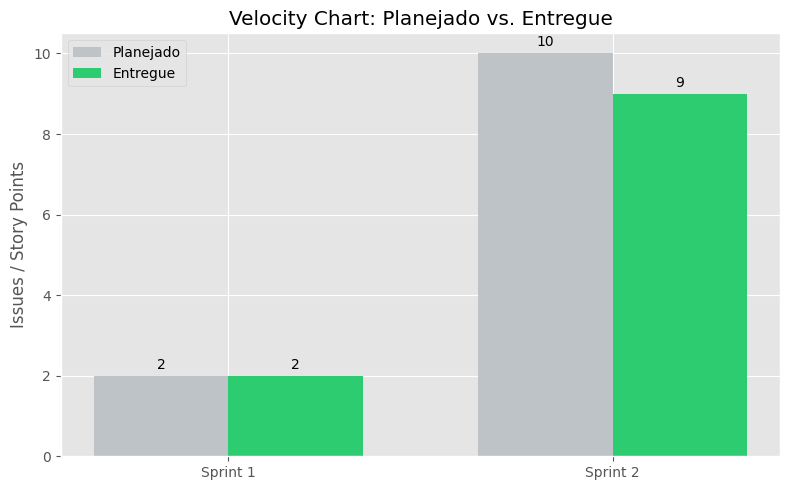

In [7]:
# @title
import matplotlib.pyplot as plt
import numpy as np

sprints = ["Sprint 1", "Sprint 2"]
planned = [2, 10]
achieved = [2, 9]

x = np.arange(len(sprints))
width = 0.35

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width/2, planned, width, label='Planejado', color='#bdc3c7')
rects2 = ax.bar(x + width/2, achieved, width, label='Entregue', color='#2ecc71')

ax.set_ylabel('Issues / Story Points')
ax.set_title('Velocity Chart: Planejado vs. Entregue')
ax.set_xticks(x)
ax.set_xticklabels(sprints)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.tight_layout()
plt.show()

## Gestão de Valor Agregado (EVM) Ágil

O **EVM (Earned Value Management)** é uma metodologia que integra escopo, cronograma e recursos para medir o desempenho e o progresso do projeto. No contexto ágil, adaptamos os conceitos para **Story Points (SP)**.

### Componentes do Cálculo
* **VP (Valor Planejado):** Esforço total planejado para as sprints concluídas até o momento.
* **VA (Valor Agregado):** Esforço das issues efetivamente entregues (Done).
* **CR (Custo Real):** Esforço total despendido (equivalente ao total de pontos em execução ou horas).

### Indicadores de Performance
Para avaliar a saúde do projeto, utilizamos dois índices principais que orbitam o valor **1.0**:

1.  **SPI (Schedule Performance Index):** Mede a eficiência do cronograma.
    * O projeto está adiantado ou conforme o planejado: $$SPI \ge 1.0$$
    * O projeto está entregando menos pontos do que o planejado por ciclo: $$SPI < 1.0$$ 
2.  **CPI (Cost Performance Index):** Mede a eficiência do esforço/custo.
    * O time está sendo produtivo com os recursos atuais: $$CPI \ge 1.0$$
    * O esforço despendido está sendo maior do que o valor entregue: $$CPI < 1.0$$

---
> Se o SPI se mantiver abaixo de 1.0 consistentemente, o dashboard aciona um alerta visual para que a equipe revise o escopo do MVP ou a capacidade de entrega nas próximas sprints.

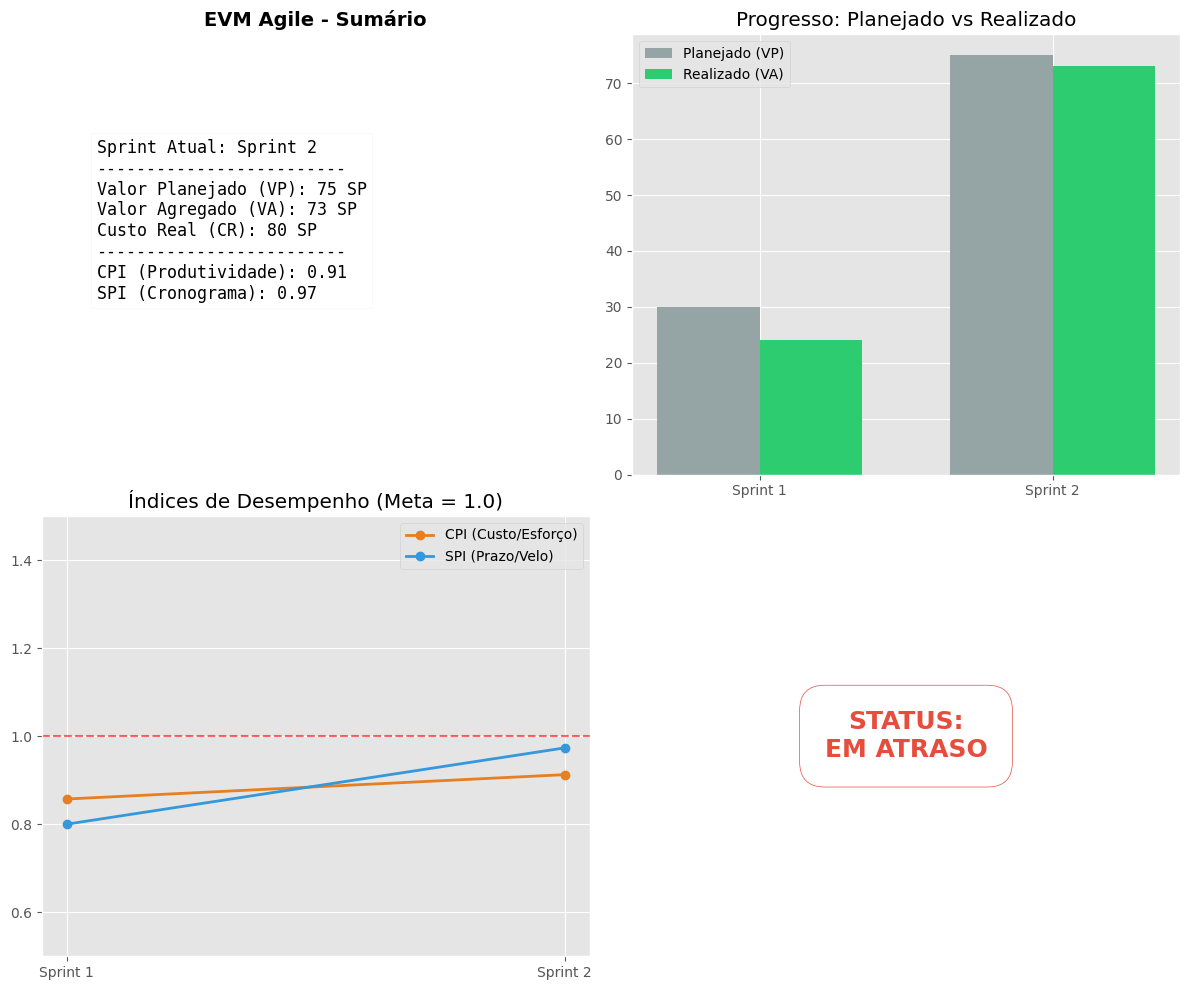

In [8]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Sprint": ["Sprint 1", "Sprint 2"],
    "VP": [30, 75],
    "VA": [24, 73],
    "CR": [28, 80]
}

df = pd.DataFrame(data)

df["CPI"] = df["VA"] / df["CR"]
df["SPI"] = df["VA"] / df["VP"]

plt.style.use('ggplot')
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].axis('off')
axs[0, 0].set_title("EVM Agile - Sumário", fontsize=14, fontweight='bold')

last_row = df.iloc[-1]
kpi_text = (
    f"Sprint Atual: {last_row['Sprint']}\n"
    f"{'-'*25}\n"
    f"Valor Planejado (VP): {int(last_row['VP'])} SP\n"
    f"Valor Agregado (VA): {int(last_row['VA'])} SP\n"
    f"Custo Real (CR): {int(last_row['CR'])} SP\n"
    f"{'-'*25}\n"
    f"CPI (Produtividade): {last_row['CPI']:.2f}\n"
    f"SPI (Cronograma): {last_row['SPI']:.2f}"
)
axs[0, 0].text(0.1, 0.4, kpi_text, fontsize=12, family='monospace', bbox=dict(facecolor='white', alpha=0.5))

x = np.arange(len(df["Sprint"]))
width = 0.35
axs[0, 1].bar(x - width/2, df["VP"], width, label="Planejado (VP)", color='#95a5a6')
axs[0, 1].bar(x + width/2, df["VA"], width, label="Realizado (VA)", color='#2ecc71')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(df["Sprint"])
axs[0, 1].set_title("Progresso: Planejado vs Realizado")
axs[0, 1].legend()

axs[1, 0].plot(df["Sprint"], df["CPI"], marker='o', label="CPI (Custo/Esforço)", color='#e67e22', linewidth=2)
axs[1, 0].plot(df["Sprint"], df["SPI"], marker='o', label="SPI (Prazo/Velo)", color='#3498db', linewidth=2)
axs[1, 0].axhline(1, color='red', linestyle='--', alpha=0.6)
axs[1, 0].set_ylim(0.5, 1.5)
axs[1, 0].set_title("Índices de Desempenho (Meta = 1.0)")
axs[1, 0].legend()

axs[1, 1].axis('off')
status = "DENTRO DO PRAZO" if last_row["SPI"] >= 1 else "EM ATRASO"
color = "#2ecc71" if last_row["SPI"] >= 1 else "#e74c3c"

axs[1, 1].text(0.5, 0.5, f"STATUS:\n{status}",
              fontsize=18, fontweight='bold', color=color,
              ha='center', va='center', bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()

## Matriz de Risco (Sprint 2)

A matriz de risco apresenta a distribuição dos riscos identificados no projeto
com base em sua probabilidade de ocorrência e impacto, permitindo priorizar
ações de mitigação.

Cada ponto representa um risco (R01–R12), posicionado conforme seus valores de
probabilidade (eixo Y) e impacto (eixo X). As cores indicam o nível de criticidade:
- Verde: baixo risco
- Amarelo: risco médio
- Vermelho: risco elevado

Observa-se que a maioria dos riscos está concentrada nas faixas de baixo e médio
impacto, indicando um cenário relativamente controlado. No entanto, riscos com
maior criticidade, como aqueles posicionados nas regiões superiores da matriz,
exigem atenção prioritária da equipe.

Essa visualização permite:
- identificar rapidamente os riscos mais críticos
- apoiar decisões de priorização de mitigação
- acompanhar a evolução do perfil de risco ao longo das sprints

A matriz deve ser continuamente atualizada a cada sprint, refletindo mudanças no
contexto do projeto e a efetividade das ações de mitigação adotadas.

| Risco | Descrição | Categoria |
| :---: | :---: | :---: |
| R01 | Dificuldade com as tecnologias definidas | Técnico |
| R02 | Saída de algum integrante do projeto | Gerencial |
| R03 | Divergência nos horários disponíveis dos integrantes | Organizacional |
| R04 | Alteração no escopo do projeto | Gerencial |
| R05 | Integrante com problema de saúde | Externo |
| R06 | Indisponibilidade do cliente ou de especialistas para esclarecimento de requisitos | Externo |
| R07 | Sobrecarga de membros da equipe | Gerencial |
| R08 | Falha de equipamento | Externo |
| R09 | Dependência entre atividades | Organizacional |
| R10 | Problemas com a infraestrutura de rede | Técnico |
| R11 | Resultados insatisfatórios da solução desenvolvida | Técnico |
| R12 | Falta de dados adequados para desenvolvimento e validação | Externo |

In [ ]:
# @title
import plotly.graph_objects as go
import pandas as pd
import numpy as np

riscos_data = [
    ("R01", 4, 4, "Dificuldade com as tecnologias definidas", "Técnico"),
    ("R02", 1, 5, "Saída de algum integrante do projeto", "Gerencial"),
    ("R03", 2, 3, "Divergência nos horários disponíveis dos integrantes", "Organizacional"),
    ("R04", 3, 3, "Alteração no escopo do projeto", "Gerencial"),
    ("R05", 2, 2, "Integrante com problema de saúde", "Externo"),
    ("R06", 2, 5, "Indisponibilidade do cliente ou especialistas", "Externo"),
    ("R07", 2, 3, "Sobrecarga de membros da equipe", "Gerencial"),
    ("R08", 1, 3, "Falha de equipamento", "Externo"),
    ("R09", 1, 3, "Dependência entre atividades", "Organizacional"),
    ("R10", 1, 2, "Problemas com a infraestrutura de rede", "Técnico"),
    ("R11", 1, 4, "Resultados insatisfatórios da solução", "Técnico"),
    ("R12", 2, 4, "Falta de dados adequados para validação", "Externo"),
]

df = pd.DataFrame(riscos_data, columns=["ID", "Probabilidade", "Impacto", "Descrição", "Categoria"])

np.random.seed(101)
df["Prob_J"] = df["Probabilidade"] + np.random.uniform(-0.35, 0.35, len(df))
df["Imp_J"] = df["Impacto"] + np.random.uniform(-0.35, 0.35, len(df))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["Imp_J"],
    y=df["Prob_J"],
    mode='markers+text',
    text=df["ID"],
    textposition="middle center",
    marker=dict(size=35, color='white', line=dict(width=2.5, color='black')),
    textfont=dict(color='black', size=10, family="Arial, sans-serif", weight="bold"),
    hovertext=[f"<b>{row['ID']}</b><br>Categoria: {row['Categoria']}<br>Descrição: {row['Descrição']}" for _, row in df.iterrows()],
    hoverinfo="text",
    name="Riscos"
))

fig.update_layout(
    shapes=[
        # Baixo (Verde)
        dict(type="rect", x0=0.5, y0=0.5, x1=2.5, y1=2.5, fillcolor="#27ae60", opacity=0.5, layer="below", line_width=0),
        # Médio (Amarelo)
        dict(type="rect", x0=2.5, y0=0.5, x1=3.5, y1=3.5, fillcolor="#f1c40f", opacity=0.5, layer="below", line_width=0),
        dict(type="rect", x0=0.5, y0=2.5, x1=2.5, y1=3.5, fillcolor="#f1c40f", opacity=0.5, layer="below", line_width=0),
        # Alto (Laranja)
        dict(type="rect", x0=3.5, y0=0.5, x1=4.5, y1=4.5, fillcolor="#e67e22", opacity=0.5, layer="below", line_width=0),
        dict(type="rect", x0=0.5, y0=3.5, x1=3.5, y1=4.5, fillcolor="#e67e22", opacity=0.5, layer="below", line_width=0),
        # Crítico (Vermelho)
        dict(type="rect", x0=4.5, y0=0.5, x1=5.5, y1=5.5, fillcolor="#c0392b", opacity=0.5, layer="below", line_width=0),
        dict(type="rect", x0=0.5, y0=4.5, x1=4.5, y1=5.5, fillcolor="#c0392b", opacity=0.5, layer="below", line_width=0),
    ],
    title="Matriz de Riscos Interativa - RetinaScan (Sprint 2)",
    xaxis=dict(title="Impacto (Gravidade)", range=[0.5, 5.5], tickvals=[1,2,3,4,5], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(title="Probabilidade (Frequência)", range=[0.5, 5.5], tickvals=[1,2,3,4,5], gridcolor='rgba(0,0,0,0.1)'),
    width=850,
    height=750,
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12, font_family="Arial")
)

fig.show("png")